# Кластеризация лиц по атрибутам (CelebA)

**Цель работы:** освоить три подхода к кластеризации — **K-Means**, **DBSCAN** и **иерархическую кластеризацию** — на реальном датасете CelebFaces Attributes (CelebA).

### Что вы научитесь делать:
1. Загружать и исследовать табличный датасет с бинарными признаками
2. Работать с этически чувствительными атрибутами и понимать связанные риски
3. Применять **K-Means**, **DBSCAN** и строить **дендрограммы**
4. Сравнивать результаты разных алгоритмов и делать выводы

### Датасет
**CelebA** — 202 599 изображений знаменитостей, каждому приписано 40 бинарных атрибутов внешности (улыбка, очки, пол, возраст и т.д.).

> ⚠️ **Этический контекст:** кластеризация людей по внешности несёт серьёзные риски: воспроизведение стереотипов, скрытая дискриминация, нарушение приватности. Мы будем обращать на это внимание на протяжении всего практикума.

---
📋 **Обозначения:**
- 🔧 — ячейка с кодом, который нужно **дописать** (`# TODO`)
- 💡 — подсказка
- 🤔 — вопрос для размышления
- ✅ — готовый код (просто запустите)

---
## 0. Настройка окружения

✅ Запустите ячейку ниже, чтобы импортировать все необходимые библиотеки.

In [ ]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

sns.set_style("whitegrid")
np.random.seed(42)

print("✅ Все библиотеки загружены!")

✅ Все библиотеки загружены!


### Где скачать датасет CelebA

Вам понадобятся файл атрибутов `list_attr_celeba.csv` и папка с изображениями `img_align_celeba.zip`.

| Источник | Ссылка | Комментарий |
|----------|--------|-------------|
| **Официальный сайт MMLAB** | http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html | Google Drive, Dropbox, Baidu Drive |
| **Kaggle** | https://www.kaggle.com/datasets/jessicali9530/celeba-dataset | Нужен аккаунт Kaggle |
| **Hugging Face** | https://huggingface.co/datasets/flwrlabs/celeba | `pip install datasets`, загрузка через API |
| **TensorFlow Datasets** | https://www.tensorflow.org/datasets/catalog/celeb_a | `tfds.load('celeb_a')` — скачает автоматически |
| **Papers With Code** | https://paperswithcode.com/dataset/celeba | Агрегатор ссылок на скачивание |

> ⚠️ Датасет доступен **только для некоммерческих исследовательских целей**. Изображения весят ~1.4 ГБ.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.33G/1.33G [00:40<00:00, 34.9MB/s]

Extracting files...


Path to dataset files: /Users/romanov/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


### Конфигурация путей

🔧 **Укажите путь к папке с данными CelebA.**

In [ ]:
# TODO: укажите путь к папке с данными CelebA
CELEBA_ROOT = "/path/to/celeba_data"

DATA_PATH  = os.path.join(CELEBA_ROOT, "list_attr_celeba.csv")
IMG_DIR    = os.path.join(CELEBA_ROOT, "img_align_celeba", "img_align_celeba")

SAMPLE_SIZE = 20_000   # подвыборка для скорости (None = весь датасет)
OUT_DIR     = "celeba_output"
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f"Файл не найден: {DATA_PATH}"
HAS_IMAGES = os.path.isdir(IMG_DIR)
if not HAS_IMAGES:
    print("⚠ Папка изображений не найдена — визуализация фото будет пропущена")
else:
    print(f"✅ Изображения: {IMG_DIR}")
print(f"✅ Атрибуты: {DATA_PATH}")

✅ Изображения: /Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/МО Весна 2026/lection/clustering/celeba_data/img_align_celeba/img_align_celeba
✅ Атрибуты: /Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/МО Весна 2026/lection/clustering/celeba_data/list_attr_celeba.csv


---
## 1. Загрузка и первый взгляд на данные

В файле `list_attr_celeba.csv` каждая строка — одно изображение, столбцы — 40 атрибутов. Значения: **−1** (нет) и **+1** (есть). Перекодируем в **0/1**.

In [3]:
def load_celeba(path):
    """Загружает атрибуты CelebA и переводит −1/1 → 0/1."""
    df = pd.read_csv(path, index_col="image_id")
    return ((df + 1) // 2).astype(np.int8)

df_full = load_celeba(DATA_PATH)
print(f"Всего изображений : {len(df_full):,}")
print(f"Число атрибутов   : {df_full.shape[1]}")
df_full.head()

Всего изображений : 202,599
Число атрибутов   : 40


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [4]:
if SAMPLE_SIZE and SAMPLE_SIZE < len(df_full):
    df = df_full.sample(SAMPLE_SIZE, random_state=42)
    print(f"Подвыборка: {SAMPLE_SIZE:,} объектов")
else:
    df = df_full.copy()
    print(f"Полный датасет: {len(df):,} объектов")

attr_cols = df.columns.tolist()
print(f"\nАтрибуты ({len(attr_cols)} шт.): {', '.join(attr_cols)}")

Подвыборка: 20,000 объектов

Атрибуты (40 шт.): 5_o_Clock_Shadow, Arched_Eyebrows, Attractive, Bags_Under_Eyes, Bald, Bangs, Big_Lips, Big_Nose, Black_Hair, Blond_Hair, Blurry, Brown_Hair, Bushy_Eyebrows, Chubby, Double_Chin, Eyeglasses, Goatee, Gray_Hair, Heavy_Makeup, High_Cheekbones, Male, Mouth_Slightly_Open, Mustache, Narrow_Eyes, No_Beard, Oval_Face, Pale_Skin, Pointy_Nose, Receding_Hairline, Rosy_Cheeks, Sideburns, Smiling, Straight_Hair, Wavy_Hair, Wearing_Earrings, Wearing_Hat, Wearing_Lipstick, Wearing_Necklace, Wearing_Necktie, Young


### 🤔 Вопрос 1: Знакомство с данными

Посмотрите на список атрибутов:
1. Какие атрибуты описывают **объективные** характеристики (например, «носит очки»)?
2. Какие атрибуты **субъективны** (зависят от мнения аннотатора)?
3. Почему субъективные атрибуты могут быть проблемой для кластеризации?

**Ваш ответ:**

...

---
## 2. Разведочный анализ (EDA)

### 2.1 Частота атрибутов

/var/folders/jb/7djwyf6j1057xl9x3ft0_f840000gn/T/ipykernel_65175/2511443761.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(attr_freq.index, rotation=45, ha="right", fontsize=8)


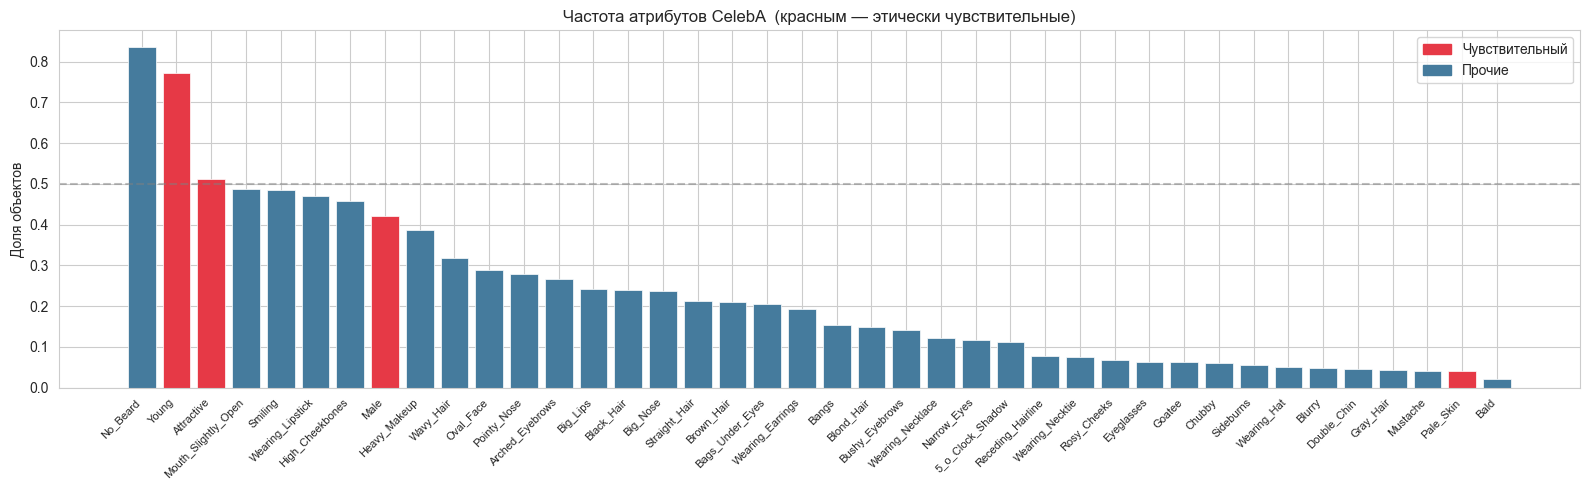

In [5]:
SENSITIVE = ["Male", "Young", "Attractive", "Pale_Skin"]

attr_freq = df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
colors = ["#E63946" if c in SENSITIVE else "#457b9d" for c in attr_freq.index]
ax.bar(attr_freq.index, attr_freq.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticklabels(attr_freq.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Доля объектов")
ax.set_title("Частота атрибутов CelebA  (красным — этически чувствительные)")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.legend(handles=[
    mpatches.Patch(color="#E63946", label="Чувствительный"),
    mpatches.Patch(color="#457b9d", label="Прочие"),
])
plt.tight_layout()
plt.show()

### 🤔 Вопрос 2: Дисбаланс атрибутов

1. Какие атрибуты встречаются у **подавляющего большинства**? Какие крайне **редкие**?
2. Как дисбаланс может повлиять на кластеризацию? Будет ли K-Means «обращать внимание» на редкие атрибуты?


**Ваш ответ:**

...

### 2.2 Корреляции между атрибутами

🔧 Постройте корреляционную матрицу для **15 самых частых** атрибутов.

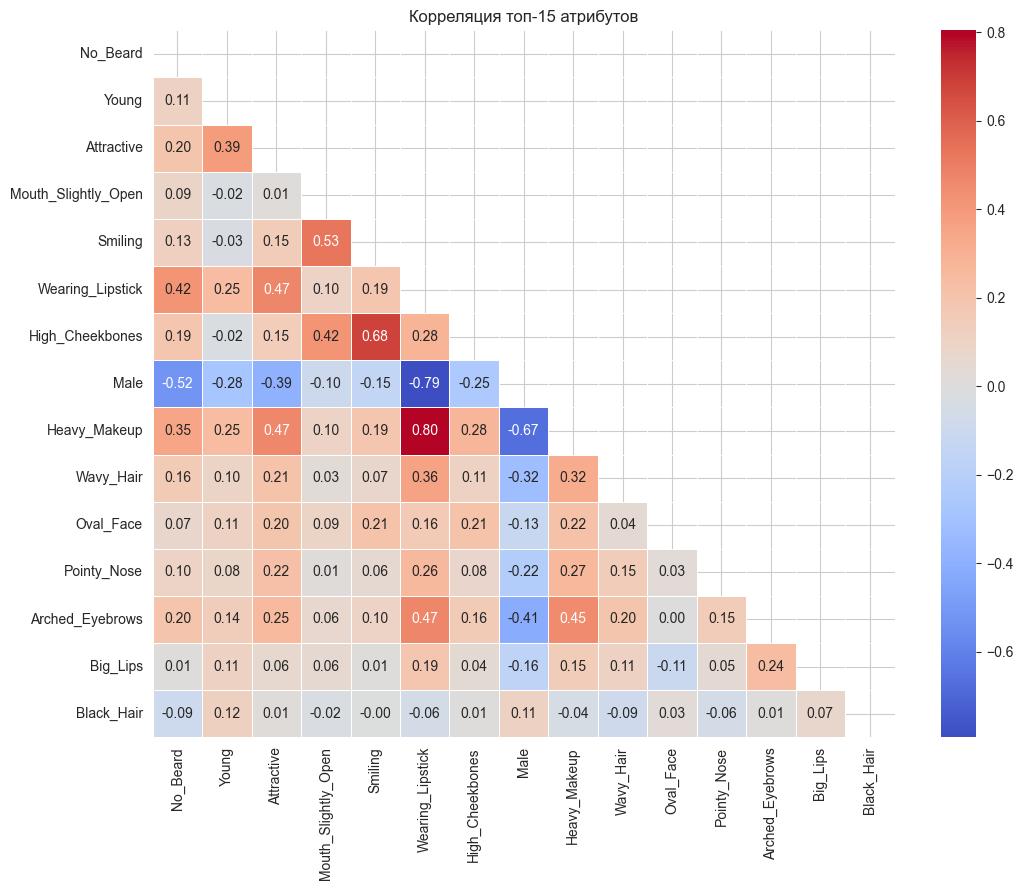

In [6]:
top15 = list(attr_freq.head(15).index)
corr = df[top15].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.4)
ax.set_title("Корреляция топ-15 атрибутов")
plt.tight_layout()
plt.show()

### 🤔 Вопрос 3: Интерпретация корреляций

1. Найдите **наиболее сильные положительные** и **отрицательные** корреляции. Логичны ли они?
2. Атрибут `Attractive` — с чем он коррелирует? О чём это говорит с точки зрения **предвзятости аннотаторов**?

**Ваш ответ:**

...

### 2.3 Смотрим на изображения

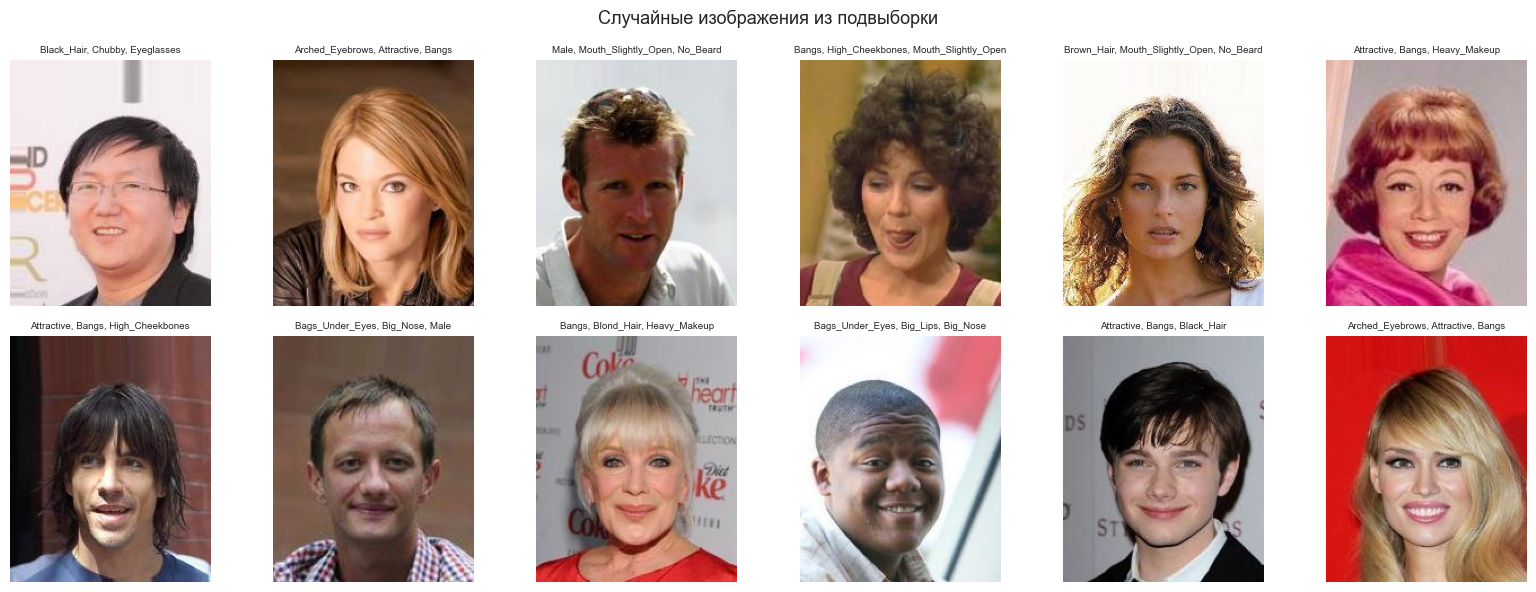

In [7]:
if HAS_IMAGES:
    rng = np.random.default_rng(42)
    sample_ids = rng.choice(df.index.tolist(), size=12, replace=False)

    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    for ax, img_id in zip(axes.flat, sample_ids):
        img_path = os.path.join(IMG_DIR, img_id)
        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
            attrs_on = [c for c in attr_cols if df.loc[img_id, c] == 1]
            ax.set_title(", ".join(attrs_on[:3]), fontsize=7)
        except Exception:
            ax.text(0.5, 0.5, "нет файла", ha="center", va="center")
        ax.axis("off")
    plt.suptitle("Случайные изображения из подвыборки", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Изображения не найдены — пропускаем")

---
## 3. Этически чувствительные атрибуты

| Атрибут | Проблема |
|---------|----------|
| `Male` | Бинарная шкала M/F — не отражает гендерное разнообразие |
| `Young` | Субъективная оценка аннотатора |
| `Attractive` | Полностью субъективно; отражает культурные стереотипы о красоте |
| `Pale_Skin` | Прокси для расы/этничности |

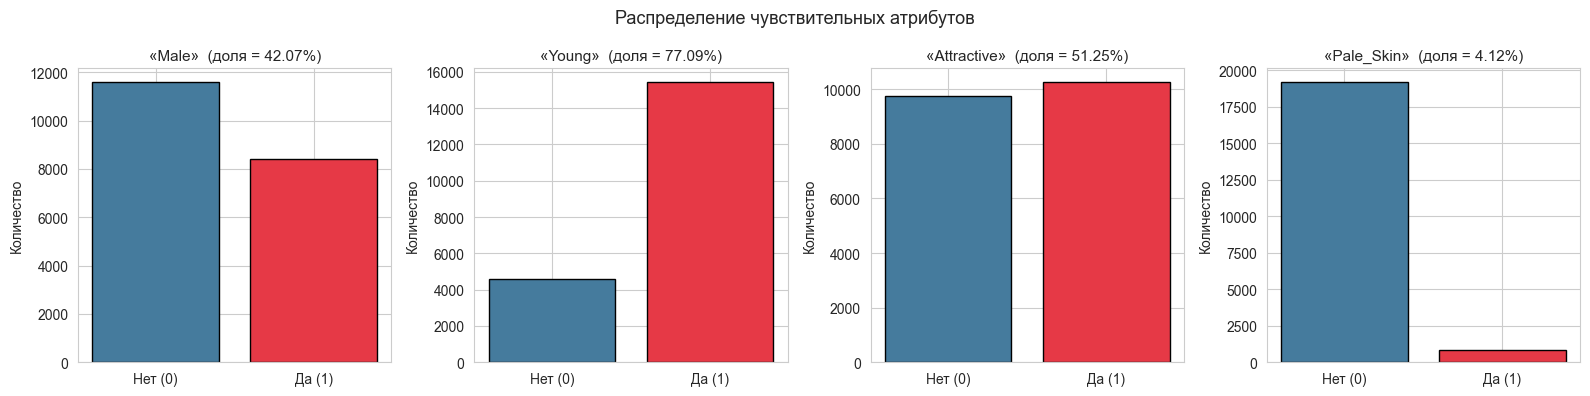

In [8]:
sens_present = [c for c in SENSITIVE if c in df.columns]

fig, axes = plt.subplots(1, len(sens_present), figsize=(4 * len(sens_present), 4))
for ax, col in zip(axes, sens_present):
    counts = df[col].value_counts().sort_index()
    ax.bar(["Нет (0)", "Да (1)"], counts.values,
           color=["#457b9d", "#E63946"], edgecolor="black")
    ax.set_title(f'«{col}»  (доля = {df[col].mean():.2%})', fontsize=11)
    ax.set_ylabel("Количество")
plt.suptitle("Распределение чувствительных атрибутов", fontsize=13)
plt.tight_layout()
plt.show()

### 🔧 Задание: Корреляции чувствительных атрибутов

Для каждого чувствительного атрибута найдите **5 наиболее коррелирующих** с ним признаков.

💡 *Подсказка:* `df.corrwith(df[col]).abs().nlargest(6)` — первый результат будет сам атрибут, уберите его.

In [10]:
# TODO


### 🤔 Вопрос 4: Этика данных

1. Атрибут `Attractive` сильно коррелирует с некоторыми другими. С какими? Что это говорит о **предвзятости** в данных?
2. Стоит ли **удалять** чувствительные атрибуты перед кластеризацией? Аргументы за и против?


**Ваш ответ:**

...

---
## 4. Предобработка

Перед кластеризацией стандартизируем данные: приведём каждый признак к среднему = 0 и стандартному отклонению = 1. Это важно, потому что алгоритмы кластеризации работают с расстояниями, и признаки с большим разбросом будут доминировать.

Также подготовим **2D-проекцию** через PCA — она понадобится для визуализации кластеров на плоскости (40 измерений на графике не отобразить).

In [11]:
X_raw = df.values.astype(np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA на 2 компоненты — только для визуализации на scatter-графиках
pca2d = PCA(n_components=2, random_state=42)
X_2d = pca2d.fit_transform(X_scaled)

print(f"Данные для кластеризации : {X_scaled.shape}  (все 40 признаков)")
print(f"2D-проекция для графиков : {X_2d.shape}")
print(f"PC1 объясняет {pca2d.explained_variance_ratio_[0]:.1%}, PC2 — {pca2d.explained_variance_ratio_[1]:.1%} дисперсии")

Данные для кластеризации : (20000, 40)  (все 40 признаков)
2D-проекция для графиков : (20000, 2)
PC1 объясняет 15.3%, PC2 — 7.0% дисперсии


---
## 5. K-Means кластеризация

### 5.1 Выбор числа кластеров K

Два классических метода:
1. **Метод локтя (Elbow):** график инерции (суммы квадратов расстояний до центроидов) при разных K. Ищем «перелом».
2. **Силуэтный коэффициент:** от −1 до 1, чем больше — тем лучше.

🔧 Запустите цикл для K от 2 до 10.

In [ ]:
K_RANGE = range(2, 11)
inertias = []
silhouettes = []

# TODO

print(f"\nЛучший K по силуэту: {best_k_sil}")

  K= 2: инерция=    706402.5   силуэт=0.1200
  K= 3: инерция=    668794.2   силуэт=0.0939
  K= 4: инерция=    647150.6   силуэт=0.0490
  K= 5: инерция=    616368.8   силуэт=0.0605
  K= 6: инерция=    599030.9   силуэт=0.0649
  K= 7: инерция=    581840.4   силуэт=0.0690
  K= 8: инерция=    565442.4   силуэт=0.0757
  K= 9: инерция=    557943.7   силуэт=0.0718
  K=10: инерция=    548304.4   силуэт=0.0722

Лучший K по силуэту: 2


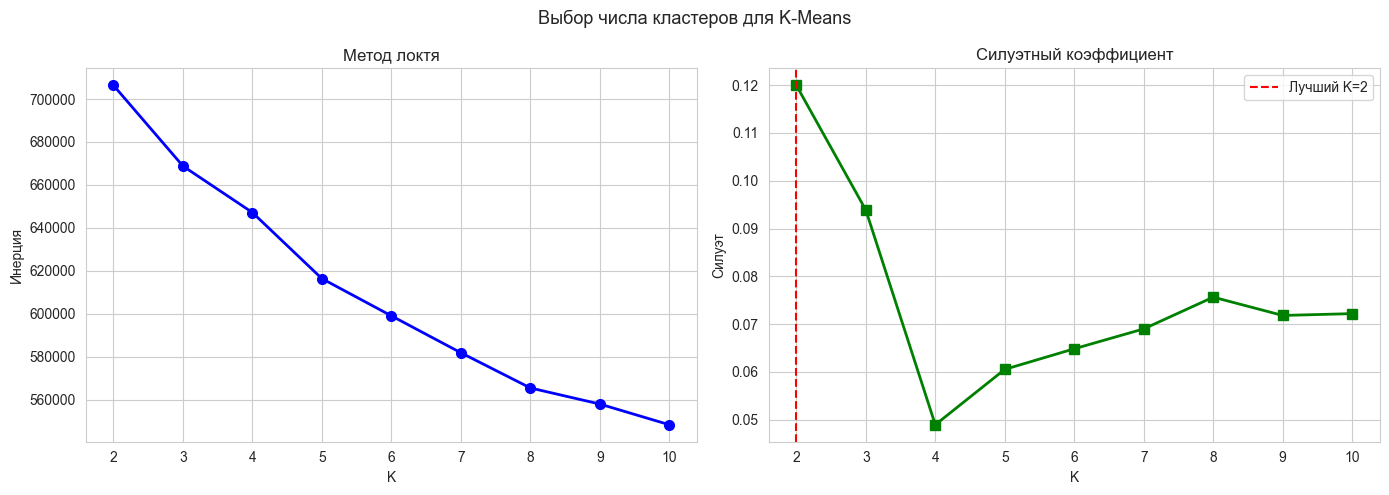

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertias, "bo-", markersize=7, linewidth=2)
axes[0].set_xlabel("K"); axes[0].set_ylabel("Инерция")
axes[0].set_title("Метод локтя")

axes[1].plot(K_RANGE, silhouettes, "gs-", markersize=7, linewidth=2)
axes[1].axvline(best_k_sil, color="red", linestyle="--", label=f"Лучший K={best_k_sil}")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Силуэт")
axes[1].set_title("Силуэтный коэффициент")
axes[1].legend()

plt.suptitle("Выбор числа кластеров для K-Means", fontsize=13)
plt.tight_layout()
plt.show()

### 🤔 Вопрос 5: Выбор K

1. Совпадает ли «оптимальный» K по методу локтя и по силуэту?
2. Выберите значение K, с которым будете работать далее. Обоснуйте выбор.

**Ваш ответ:**

...

### 5.2 Финальная кластеризация K-Means

🔧 Установите выбранное вами значение `K_FINAL`.

In [15]:
# TODO: выберите финальное K
K_FINAL = 5   # <-- замените на ваш выбор

kmeans = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
df["cluster_kmeans"] = labels_kmeans

sil_km = silhouette_score(X_scaled, labels_kmeans, sample_size=5000, random_state=42)

print(f"K-Means (K={K_FINAL}):")
print(f"  Силуэт            : {sil_km:.4f}")
print(f"\nРазмеры кластеров:")
print(df["cluster_kmeans"].value_counts().sort_index().to_string())

K-Means (K=5):
  Силуэт            : 0.0605

Размеры кластеров:
cluster_kmeans
0    1755
1    6652
2    5568
3    4576
4    1449


### 5.3 Визуализация кластеров K-Means

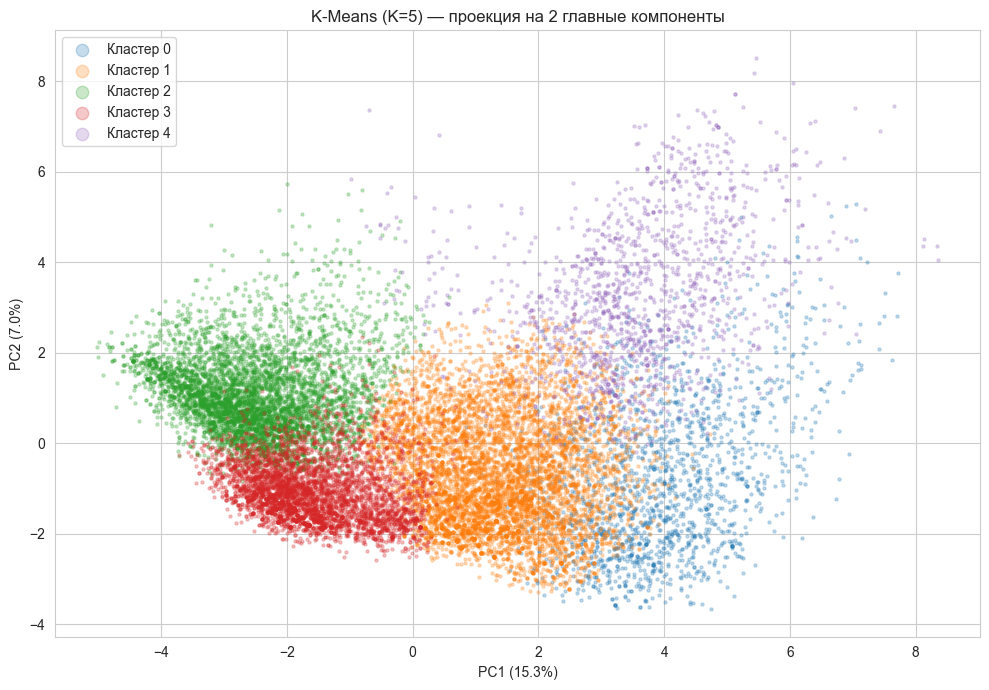

In [16]:
PALETTE = sns.color_palette("tab10", K_FINAL)

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(K_FINAL):
    mask = labels_kmeans == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=PALETTE[k], alpha=0.25, s=5, label=f"Кластер {k}")
ax.set_xlabel(f"PC1 ({pca2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"K-Means (K={K_FINAL}) — проекция на 2 главные компоненты")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

### 5.4 Профили кластеров

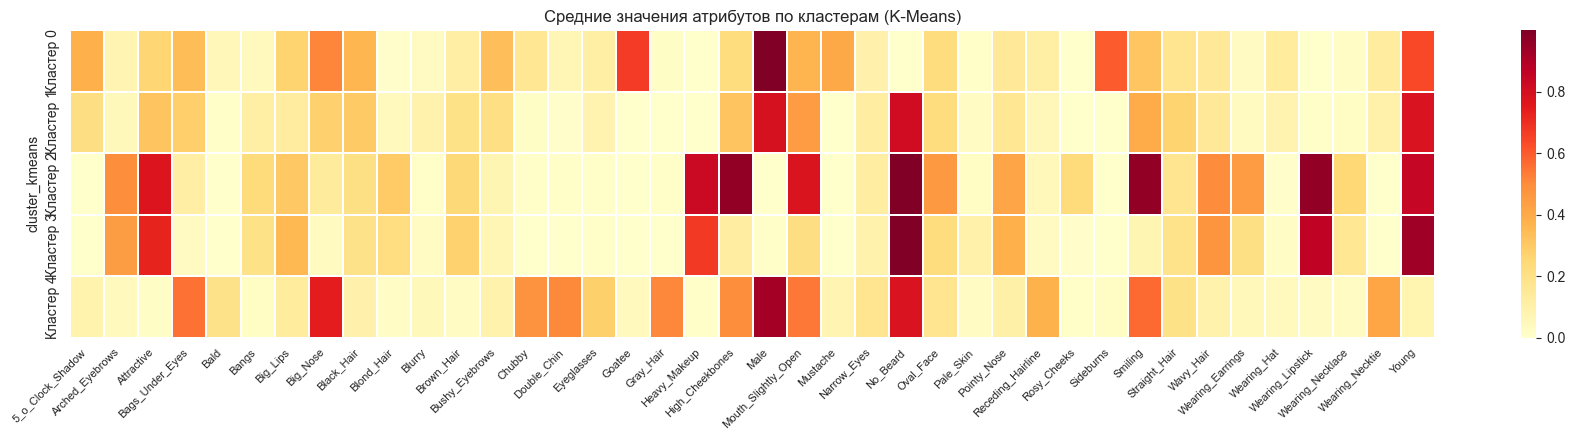

In [17]:
profiles_km = df.groupby("cluster_kmeans")[attr_cols].mean()

fig, ax = plt.subplots(figsize=(18, max(3, K_FINAL * 0.9)))
sns.heatmap(profiles_km, cmap="YlOrRd", ax=ax, linewidths=0.3, annot=False,
            yticklabels=[f"Кластер {k}" for k in range(K_FINAL)])
ax.set_title("Средние значения атрибутов по кластерам (K-Means)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

### 🔧 Задание: Топ-5 отличительных атрибутов

Для каждого кластера найдите 5 атрибутов, которые **больше всего отклоняются** от среднего по выборке.

💡 *Подсказка:* `diff = profiles_km - df[attr_cols].mean()`, затем `diff.loc[k].abs().nlargest(5)`.

In [ ]:
# TODO

### 🤔 Вопрос 6: Интерпретация кластеров K-Means

1. Можете ли вы **описать словами** каждый кластер? (Например: «молодые женщины с макияжем»)
2. Есть ли кластер, который практически определяется атрибутом `Male`?
3. Как чувствительные атрибуты распределились по кластерам?

**Ваш ответ:**

...

---
## 6. DBSCAN

**DBSCAN** — алгоритм, который:
- Не требует заранее задавать число кластеров
- Находит кластеры **произвольной формы**
- Умеет определять **выбросы** (шумовые точки, метка = −1)

Два параметра: `eps` (радиус окрестности) и `min_samples` (минимум точек для «плотной» точки).

### 6.1 Подбор параметров

🔧 Поэкспериментируйте с `eps` и `min_samples`.

💡 *Подсказка:* начните с `eps=3.0`, `min_samples=10`. Варьируйте eps от 2 до 5, min_samples от 5 до 50.

In [ ]:
eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
min_samples_values = [5, 10, 20, 30, 50]

# TODO

   eps  min_s  кластеров    шум %     силуэт
----------------------------------------------
   2.0      5        195    92.5%    -1.0000
   2.0     10         39    97.3%    -1.0000
   2.0     20          3    99.6%    -1.0000
   2.5      5        161    56.4%    -1.0000
   2.5     10         49    68.2%    -1.0000
   2.5     20         23    79.0%    -1.0000
   2.5     30         12    85.2%    -1.0000
   2.5     50          6    91.0%    -1.0000
   3.0      5        102    44.9%    -0.0484
   3.0     10         44    55.6%    -1.0000
   3.0     20         10    66.1%    -1.0000
   3.0     30          6    71.5%    -1.0000
   3.0     50          3    79.0%    -1.0000
   3.5      5         82    27.2%     0.0307
   3.5     10         29    34.4%     0.0847
   3.5     20         14    43.3%     0.0620
   3.5     30          9    48.8%     0.0756
   3.5     50          5    55.6%    -1.0000
   4.0      5         68    15.9%     0.0596
   4.0     10         25    21.1%     0.1024
   4.0  

### 🔧 Выберите лучшие параметры DBSCAN

На основе таблицы выберите `eps` и `min_samples`, которые дают разумное число кластеров (2–10), не слишком много шума (< 30%) и приличный силуэт.

In [19]:
# TODO: установите лучшие параметры
EPS_BEST = 3.5         # <-- замените
MIN_SAMPLES_BEST = 10  # <-- замените

dbscan = DBSCAN(eps=EPS_BEST, min_samples=MIN_SAMPLES_BEST)
labels_dbscan = dbscan.fit_predict(X_scaled)
df["cluster_dbscan"] = labels_dbscan

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
noise_count = (labels_dbscan == -1).sum()
print(f"DBSCAN (eps={EPS_BEST}, min_samples={MIN_SAMPLES_BEST}):")
print(f"  Кластеров      : {n_clusters_db}")
print(f"  Шумовых точек  : {noise_count:,} ({noise_count/len(df):.1%})")

mask_valid = labels_dbscan != -1
if mask_valid.sum() > 1 and n_clusters_db >= 2:
    sil_db = silhouette_score(X_scaled[mask_valid], labels_dbscan[mask_valid],
                               sample_size=5000, random_state=42)
    print(f"  Силуэт         : {sil_db:.4f}")
else:
    sil_db = None
    print("  Силуэт: не вычислен")

print(f"\nРазмеры кластеров:")
print(pd.Series(labels_dbscan).value_counts().sort_index().to_string())

DBSCAN (eps=3.5, min_samples=10):
  Кластеров      : 29
  Шумовых точек  : 6,877 (34.4%)
  Силуэт         : 0.0847

Размеры кластеров:
-1     6877
 0     9903
 1      350
 2       76
 3       16
 4      221
 5      360
 6       58
 7      914
 8       17
 9      278
 10     252
 11     249
 12      12
 13      58
 14      33
 15      42
 16      13
 17      29
 18      24
 19      27
 20      10
 21      56
 22      25
 23      15
 24      22
 25      25
 26      11
 27      17
 28      10


### 6.2 Визуализация DBSCAN

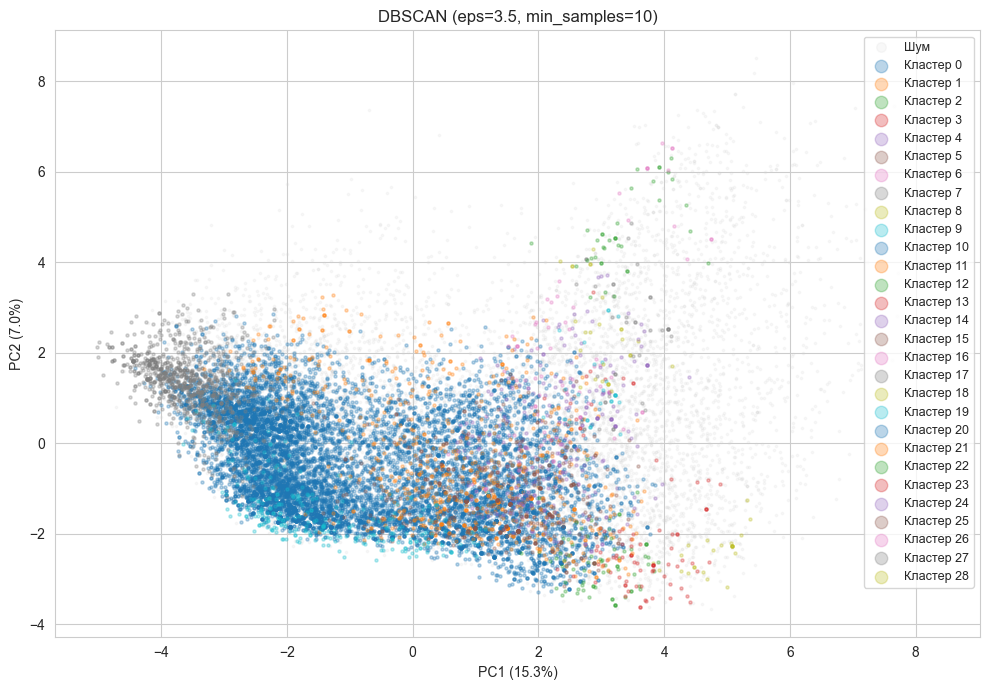

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

noise_mask = labels_dbscan == -1
ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
           color="lightgray", alpha=0.15, s=3, label="Шум")

unique_labels = sorted(set(labels_dbscan) - {-1})
palette_db = sns.color_palette("tab10", len(unique_labels))
for i, k in enumerate(unique_labels):
    mask = labels_dbscan == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=palette_db[i], alpha=0.3, s=5, label=f"Кластер {k}")

ax.set_xlabel(f"PC1 ({pca2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"DBSCAN (eps={EPS_BEST}, min_samples={MIN_SAMPLES_BEST})")
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.show()

### 🤔 Вопрос 7: K-Means vs DBSCAN

1. Сколько кластеров нашёл DBSCAN? Совпадает ли с вашим K для K-Means?
2. Что DBSCAN сделал с точками, которые не вписываются ни в один кластер?
3. Какой алгоритм лучше справился с данными CelebA? Почему?
4. Попробуйте изменить `eps` на ± 0.5. Насколько DBSCAN **чувствителен** к параметрам?

**Ваш ответ:**

...

---
## 7. Иерархическая кластеризация и дендрограммы

**Агломеративная кластеризация** строит дерево слияний — **дендрограмму**:
1. Каждый объект — свой кластер
2. На каждом шаге сливаются два ближайших
3. Продолжаем, пока не останется один кластер

> ⚠ На 20 000 объектах это очень медленно (O(n²) по памяти). Берём **подвыборку**.

In [21]:
HIER_SAMPLE = 3000
rng = np.random.default_rng(42)
idx_hier = rng.choice(len(X_scaled), size=HIER_SAMPLE, replace=False)
X_hier = X_scaled[idx_hier]
X_2d_hier = X_2d[idx_hier]
labels_km_hier = labels_kmeans[idx_hier]

print(f"Подвыборка для дендрограммы: {HIER_SAMPLE} объектов")

Подвыборка для дендрограммы: 3000 объектов


### 7.1 Построение дендрограммы

🔧 Постройте дендрограмму методом Уорда (Ward).

💡 *Метод Ward* минимизирует внутрикластерную дисперсию при каждом слиянии — по духу близок к K-Means.

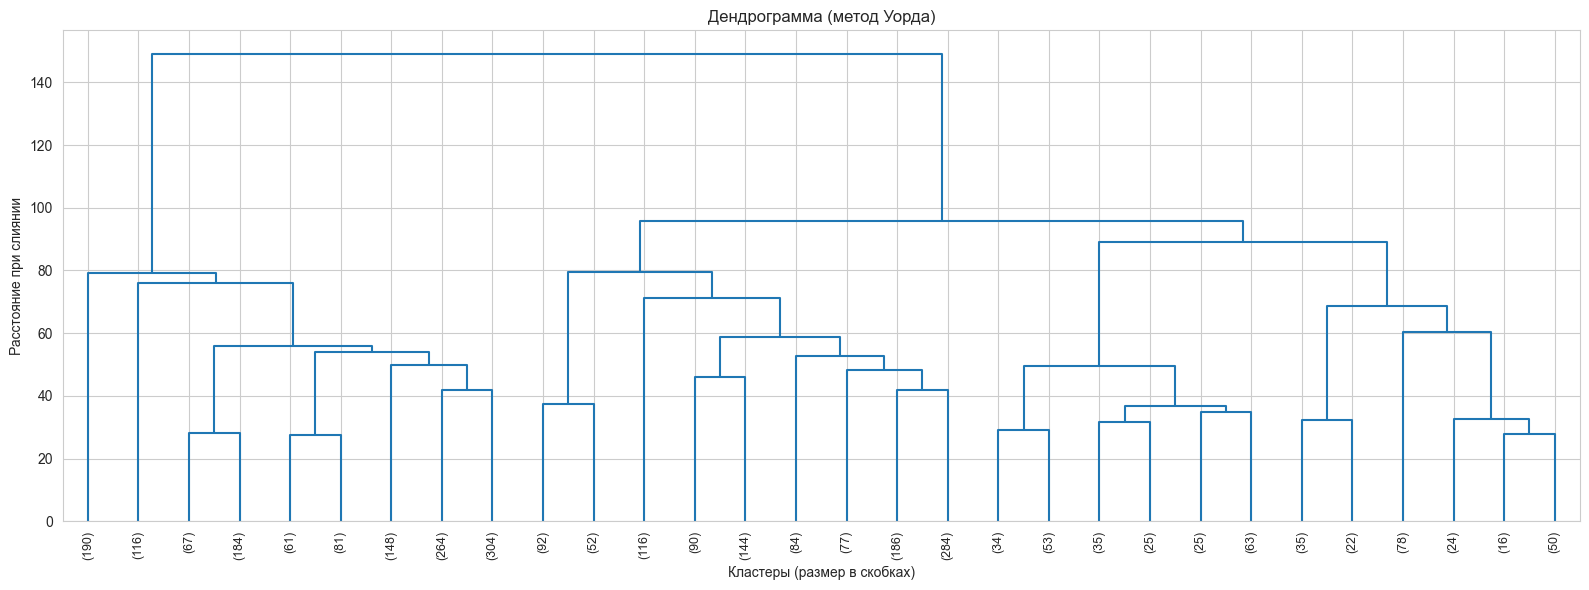

In [22]:
Z = linkage(X_hier, method="ward")

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=9, ax=ax, color_threshold=0)
ax.set_xlabel("Кластеры (размер в скобках)")
ax.set_ylabel("Расстояние при слиянии")
ax.set_title("Дендрограмма (метод Уорда)")
plt.tight_layout()
plt.show()

### 🤔 Вопрос 8: Чтение дендрограммы

1. Где вы видите **большие скачки** расстояния? Что они означают?
2. Если провести горизонтальную линию на определённой высоте — это задаёт число кластеров. На какой высоте вы бы провели линию?
3. Согласуется ли это число с результатами K-Means?

**Ваш ответ:**

...

### 7.2 Сравнение методов связи

- **ward** — минимизирует дисперсию (круглые кластеры)
- **average** — среднее расстояние между парами
- **complete** — максимальное расстояние
- **single** — минимальное расстояние (склонен к «цепочкам»)

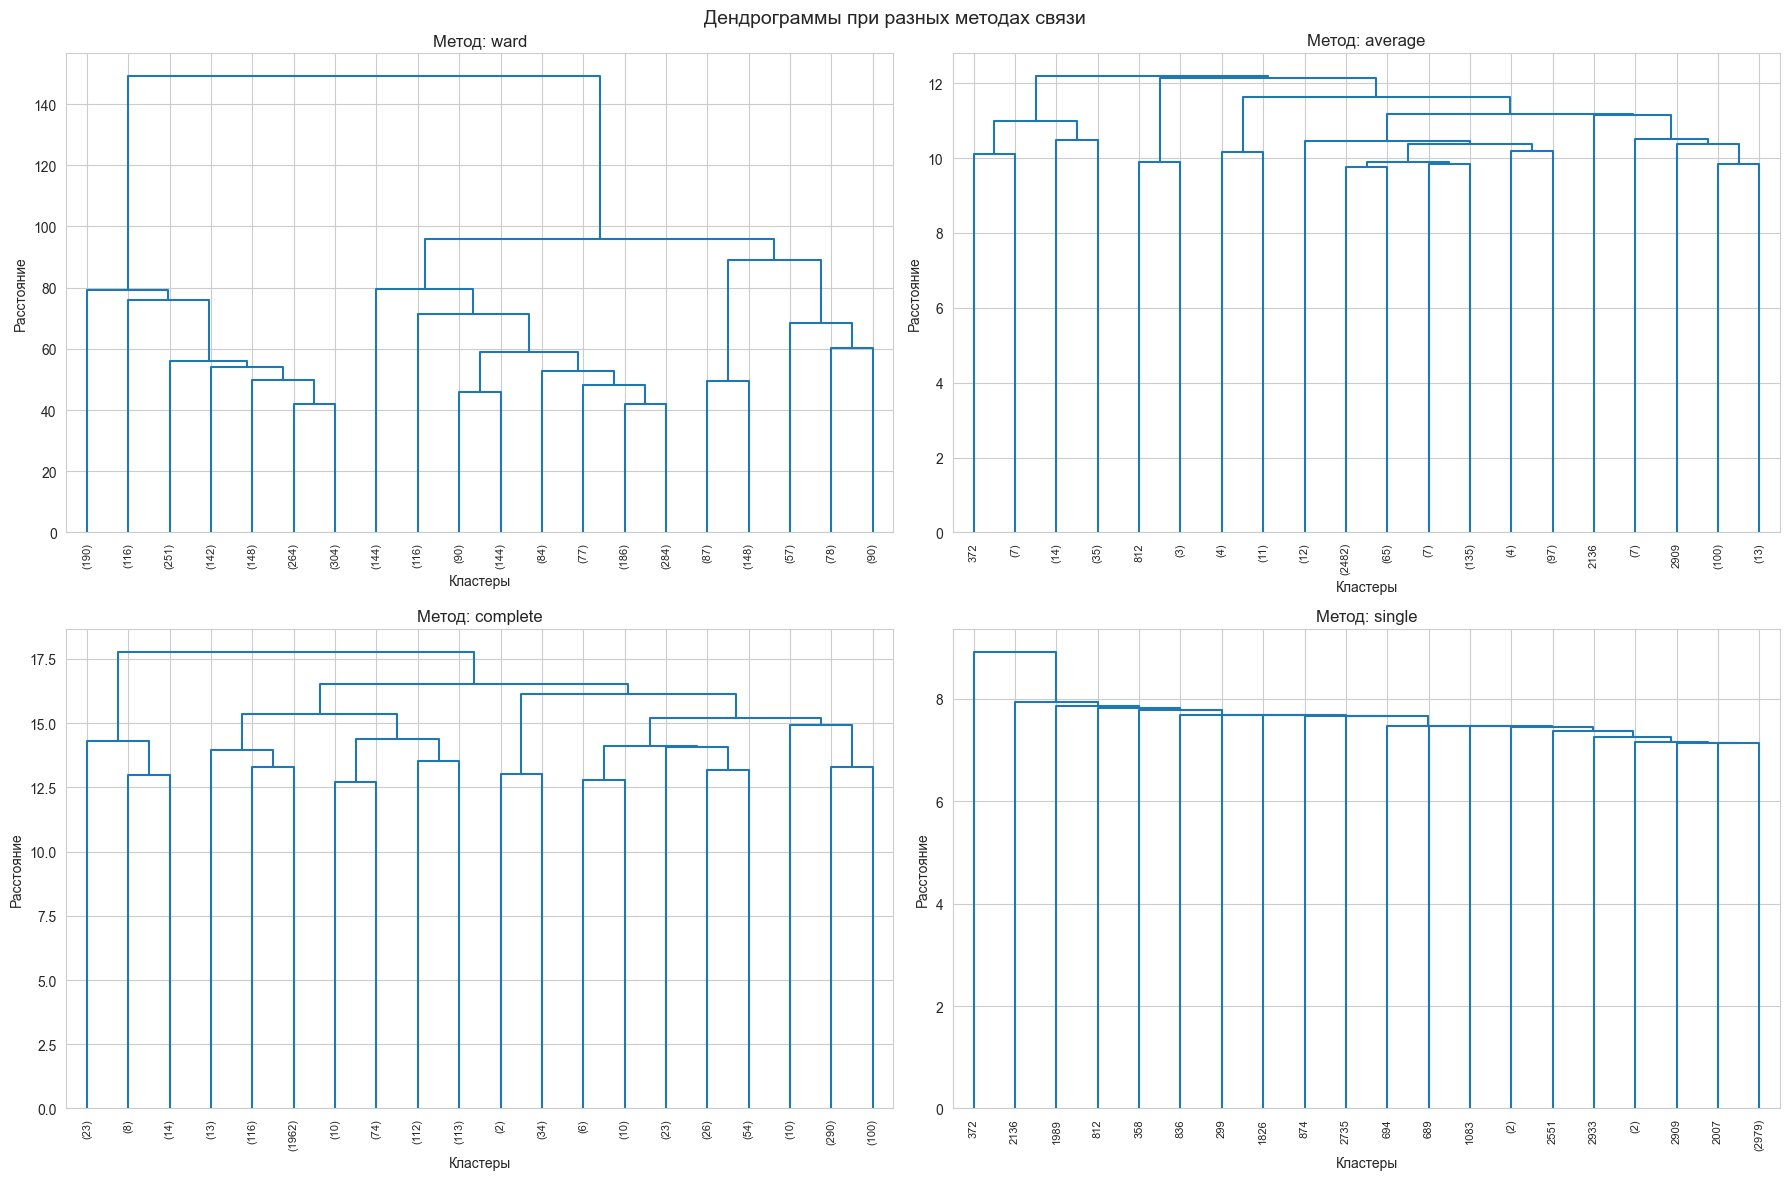

In [23]:
methods = ["ward", "average", "complete", "single"]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, method in zip(axes.flat, methods):
    Z_m = linkage(X_hier, method=method)
    dendrogram(Z_m, truncate_mode="lastp", p=20,
               leaf_rotation=90, leaf_font_size=8, ax=ax, color_threshold=0)
    ax.set_title(f"Метод: {method}", fontsize=12)
    ax.set_xlabel("Кластеры"); ax.set_ylabel("Расстояние")

plt.suptitle("Дендрограммы при разных методах связи", fontsize=14)
plt.tight_layout()
plt.show()

### 7.3 Разрезаем дендрограмму

In [24]:
labels_hier = fcluster(Z, t=K_FINAL, criterion="maxclust") - 1

print(f"Иерархическая кластеризация (Ward, K={K_FINAL}):")
print(f"\nРазмеры кластеров:")
print(pd.Series(labels_hier).value_counts().sort_index().to_string())

sil_hier = silhouette_score(X_hier, labels_hier, random_state=42)
print(f"\nСилуэт: {sil_hier:.4f}")

Иерархическая кластеризация (Ward, K=5):

Размеры кластеров:
0    1415
1     144
2     981
3     235
4     225

Силуэт: 0.0820


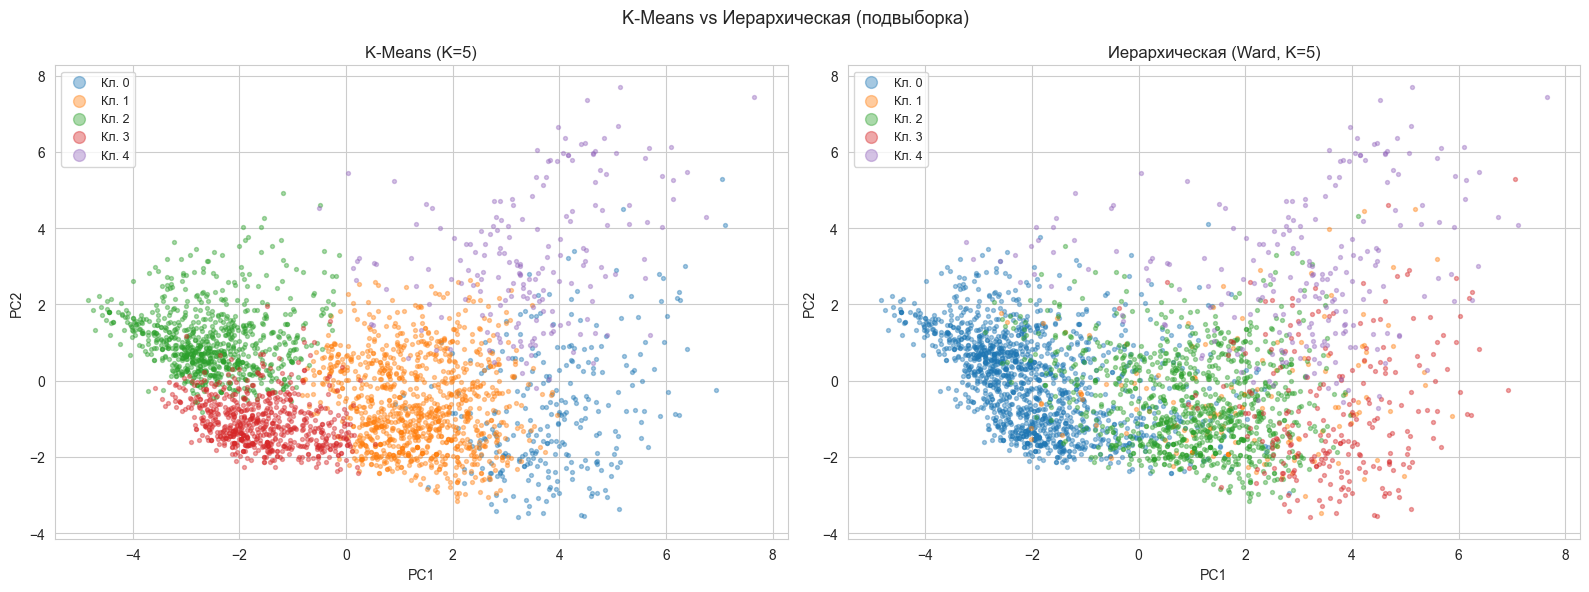

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for k in range(K_FINAL):
    mask = labels_km_hier == k
    ax.scatter(X_2d_hier[mask, 0], X_2d_hier[mask, 1],
               color=PALETTE[k], alpha=0.4, s=8, label=f"Кл. {k}")
ax.set_title(f"K-Means (K={K_FINAL})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(markerscale=3, fontsize=9)

ax = axes[1]
for k in range(K_FINAL):
    mask = labels_hier == k
    ax.scatter(X_2d_hier[mask, 0], X_2d_hier[mask, 1],
               color=PALETTE[k], alpha=0.4, s=8, label=f"Кл. {k}")
ax.set_title(f"Иерархическая (Ward, K={K_FINAL})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(markerscale=3, fontsize=9)

plt.suptitle("K-Means vs Иерархическая (подвыборка)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Сравнение трёх подходов

### 8.1 Сводная таблица метрик

In [27]:
ch_hier = calinski_harabasz_score(X_hier, labels_hier)

comp_df = pd.DataFrame({
    "Метод": ["K-Means", "DBSCAN", "Иерархич. (Ward)"],
    "Кластеров": [K_FINAL, n_clusters_db, K_FINAL],
    "Силуэт": [round(sil_km, 4),
                round(sil_db, 4) if sil_db is not None else "N/A",
                round(sil_hier, 4)],
})
print(comp_df.to_string(index=False))

           Метод  Кластеров  Силуэт
         K-Means          5  0.0605
          DBSCAN         29  0.0847
Иерархич. (Ward)          5  0.0820


### 8.2 Примеры изображений по кластерам (K-Means)

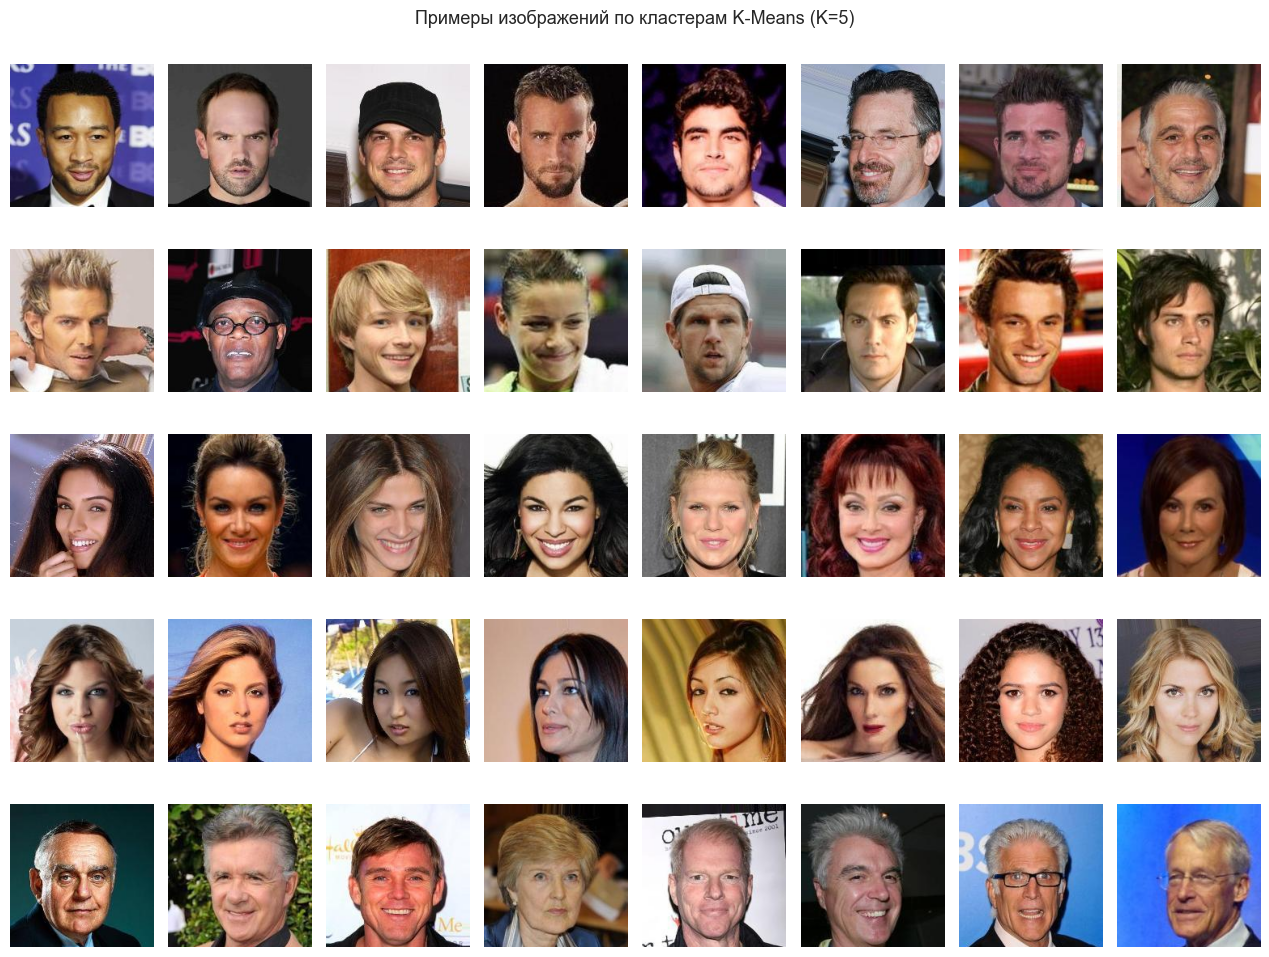

In [29]:
N_SAMPLE_IMGS = 8

if HAS_IMAGES:
    rng = np.random.default_rng(42)
    fig, axes = plt.subplots(K_FINAL, N_SAMPLE_IMGS,
                              figsize=(N_SAMPLE_IMGS * 1.6, K_FINAL * 2.0))
    for k in range(K_FINAL):
        cluster_images = df[df["cluster_kmeans"] == k].index.tolist()
        chosen = rng.choice(cluster_images,
                            size=min(N_SAMPLE_IMGS, len(cluster_images)),
                            replace=False)
        for j, ax in enumerate(axes[k]):
            ax.axis("off")
            if j >= len(chosen):
                continue
            img_path = os.path.join(IMG_DIR, chosen[j])
            if not os.path.exists(img_path):
                continue
            try:
                img = Image.open(img_path).convert("RGB")
                w, h = img.size
                side = min(w, h)
                left, top_crop = (w - side) // 2, (h - side) // 2
                img = img.crop((left, top_crop, left + side, top_crop + side))
                ax.imshow(img)
                if j == 0:
                    ax.set_ylabel(f"Кл. {k}", fontsize=9, rotation=0, labelpad=40, va="center")
            except Exception:
                pass
    plt.suptitle(f"Примеры изображений по кластерам K-Means (K={K_FINAL})", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Изображения не найдены — пропускаем")

---
## 9. Выводы и рефлексия

### 🤔 Итоговые вопросы

**По алгоритмам:**
1. Какой из трёх методов дал **наиболее интерпретируемые** кластеры? Почему?
2. В каких случаях DBSCAN предпочтительнее K-Means?
3. Зачем нужна дендрограмма, если мы всё равно получаем «плоские» кластеры?

**По этике:**

4. Кластеры фактически разделили людей по полу и возрасту — хотя мы не просили алгоритм это делать. Почему так произошло?
5. Представьте, что модель внедряют в продакшен (рекомендации контента). Какие **риски**?
6. Как уменьшить влияние чувствительных атрибутов на кластеризацию?


**Ваши выводы:**

...

---
## 🔧 Бонусные задания

1. **Fairness-эксперимент:** удалите `Male`, `Attractive`, `Pale_Skin` перед кластеризацией. Как изменились кластеры?
2. **t-SNE:** замените PCA-визуализацию на t-SNE (`from sklearn.manifold import TSNE`). Какие различия?


---
### 📚 Полезные ресурсы

- [scikit-learn: Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [CelebA Dataset](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html)
- [Fairlearn](https://fairlearn.org/)